In [47]:
# Pool data across session and animals
import argparse
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"
os.environ["PYDEVD_USE_FRAME_EVAL"] = "NO"
import re
import scipy.io as sio
import seaborn as sns
import pickle
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC, SVR, LinearSVC
from sklearn.metrics import (
    accuracy_score,
    silhouette_score,
    adjusted_rand_score,
    silhouette_samples,
)
from sklearn.cluster import AgglomerativeClustering, SpectralClustering, KMeans
from sklearn.neighbors import NearestNeighbors, kneighbors_graph
from sklearn.manifold import spectral_embedding   # same code SC uses
from sklearn.cluster._spectral import discretize 
from sklearn.model_selection import KFold, LeaveOneOut, train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.kernel_ridge import KernelRidge
from sklearn import linear_model
import scipy.stats as stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from patsy import (
    ModelDesc,
    EvalEnvironment,
    Term,
    EvalFactor,
    LookupFactor,
    dmatrices,
    INTERCEPT,
)
from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.cm as cm
import matplotlib.colors as colors
import matplotlib.colorbar as colorbar
import sys
from sklearn.model_selection import train_test_split, cross_val_score, cross_val_predict, LeaveOneOut
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.svm import SVC, LinearSVC

import importlib
import s2p_utils.processing_utils
import s2p_utils.data_loader
import plot_utils
from s2p_utils.data_loader import DataLoader

importlib.reload(s2p_utils.processing_utils)
importlib.reload(s2p_utils.data_loader)
importlib.reload(plot_utils)
from s2p_utils.data_loader import load_population_data
from s2p_utils.processing_utils import (
    reorder_clusters,
    build_knn,
    get_initial_cluster_labels,
    get_filtered_rois_per_animal_plane,
    load_population_data_filtered,
    load_population_data_multiday
)
from plot_utils import (
    tsplot,
    standardize_plot_graphics,
    plot_PC_screenplot,
    plot_PCs,
    make_silhouette_plot,
    plot_activity_clusters,
    plot_cluster_pairs,
    plot_activity_clusters_pooled_multiday,
    plot_example_cells_across_learning)

logger = logging.getLogger(__name__)

In [2]:
# Initialize parameters
data_dir = "Z:\\2p\\experiment1\\"
pre_cue_window = 3
post_cue_window = 17
delay_to_reward = 3
min_cell_prob = 0.5
neucoeff = 0.7
framerate = 5
target_frames = 300 # Should be the total time window * framerate * nCS, so 300 for the current settings
trial_types = ["CS1+", "CS2+", "CS3-"]
learning_stage = 'late'


# Set animals and days for early and late learning
if learning_stage == "early":
    result_dir = "Z:\\2p\\experiment1\\population_data\\early learning\\"
    animal_list = [
        "MZ_CA1_WD_F3",
        # "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55"
    ]
    day_list = np.ones(6, dtype=int)
    subtrials = 'all'

elif learning_stage == "intermediate":
    result_dir = "Z:\\2p\\experiment1\\population_data\\intermediate learning\\"
    animal_list = [
        "MZ_CA1_WD_F3",
        # "MZ_CA1_WD_M4/d1",
        # "MZ_CA1_WD_M5/d3",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55"
    ]
    day_list = [3, 4, 4, 4, 4, 7]
    subtrials = 'all'
      
elif learning_stage == "late":
    result_dir = "Z:\\2p\\experiment1\\population_data\\late learning\\"
    animal_list = [
        "MZ_CA1_WD_F3",
        # "MZ_CA1_WD_M4/d5",
        # "MZ_CA1_WD_M5/d6",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55"
    ]   
    day_list = [7, 5, 6, 6, 8, 12]
    subtrials = 'all'

In [3]:
# For plotting
window_size = 100
frames_to_reward = delay_to_reward * framerate
pre_window_size = pre_cue_window * framerate

In [7]:
# %debug
# Load and concatenate population data across animals
populationdata, population_animal_id, population_cellidx = load_population_data(animal_list, day_list, data_dir, result_dir, target_frames, pre_cue_window, framerate, subtrials=subtrials)
flattened_cellist = [item for animal in population_cellidx for plane in animal for item in plane]    

# optional for training on certain trial types
cs1_data = populationdata[:, :window_size]
cs2_data = populationdata[:, window_size:2*window_size]
cs3_data = populationdata[:, 2*window_size:]
# train_data = np.hstack([cs1_data, cs3_data])
# trial_types = ['CS1+','CS3-']

train_data = populationdata
trial_types = ['CS1+', 'CS2+', 'CS3-']

# Define cache file paths before running PCA
pca_path = os.path.join(result_dir, "pca_model.pickle")
transformed_path = os.path.join(result_dir, "transformed_data.npy")

In [113]:
# Load cluster labels if exist
if os.path.exists(os.path.join(result_dir, "clusterlabels.npy")):
    clusterlabel_list = np.load(os.path.join(result_dir, "clusterlabels.npy"))   
    uniquelabels = list(set(clusterlabel_list))
    assert len(clusterlabel_list)==train_data.shape[0], "Cluster labels length does not match data points."
    print("Loaded existing cluster labels, skip clustering step.")

Loaded existing cluster labels, skip clustering step.


In [9]:
## -------------------------------------------------------------------------------------------------------
## STEP 1: Dimensionality reduction with PCA
# Load saved data and models if exist
if all(os.path.exists(p) for p in [pca_path, transformed_path]):
    with open(pca_path, "rb") as f:
        pca_data = pickle.load(f)
        pca = pca_data["pca"]
        num_retained_pcs = pca_data["num_retained_pcs"]
        
    transformed_data = np.load(transformed_path)   
else:
    pca = PCA(n_components=min(train_data.shape[0], train_data.shape[1]), whiten=True)
    pca.fit(train_data)
    pca_vectors = pca.components_
    x = 100 * pca.explained_variance_ratio_
    xprime = x - (x[0] + (x[-1] - x[0]) / (x.size - 1) * np.arange(x.size))
    num_retained_pcs = np.argmin(xprime)

    # # dimension-reduced data on the first principal components
    transformed_data = pca.transform(train_data)
    np.save(os.path.join(result_dir, "transformed_data.npy"), transformed_data)
    
    # Save PCA model
    with open(pca_path, "wb") as f:
        pickle.dump({
            "pca": pca,
            "num_retained_pcs": num_retained_pcs
        }, f)       


    # Plot PC screen plot
    fig_pc_screenplot = plot_PC_screenplot(pca, x, num_retained_pcs)
    fig_pc_screenplot.savefig(os.path.join(result_dir, "PC_screenplot.png"), format="png")
    # plt.close(fig_pc_screenplot)

    # Plot PCs
    fig_pcs = plot_PCs(
        pca_vectors,
        num_retained_pcs,
        trial_types,
        window_size,
        pre_window_size,
        frames_to_reward,
        framerate,
    )
    fig_pcs.savefig(os.path.join(result_dir, "PCs.png"), format="png")
    # plt.close(fig_pcs)

In [5]:
## -------------------------------------------------------------------------------------------------------
## STEP 2: Clustering
# Choose model, options are "SC_discretize", "SC_kmeans", 
# "KMeans", "AgglomerativeClustering"
clustering_model = "SC_discretize"
clustering_path = os.path.join(result_dir, f"clustering_model_{clustering_model}.pickle")
labels_path = os.path.join(result_dir, f"clusterlabels.npy")

if all(os.path.exists(p) for p in [clustering_path, labels_path]):    
    
    with open(clustering_path, "rb") as f:
        cluster_data = pickle.load(f)
        model = cluster_data["model"]
        n_clusters = cluster_data["n_clusters"]
        n_nearest_neighbors = cluster_data["n_neighbors"]
    
    clusterlabel_list = np.load(labels_path)
    uniquelabels = list(set(clusterlabel_list))
    
else:    
    max_n_clusters = 10  # initialize nclusters, can run more but takes longer, 9 is relatively optimal
    # iTers = 100
    possible_n_clusters = np.arange(2, max_n_clusters + 1)  # has to be at least two
    possible_n_nearest_neighbors = np.array(
        [50, 100, 200, 500, 750, 1000, 1250, 1500]
    )  # depends on the size of the data, for a data with 3000 neurons, maybe use up to 1500 
    
    silhouette_scores = np.nan*np.ones((possible_n_clusters.size,
                                        possible_n_nearest_neighbors.size,
                                        ))
    
    
    # Fit clusters with your clustering model of choice
    for nnidx, nn in enumerate(possible_n_nearest_neighbors):
        G = build_knn(transformed_data[:,:num_retained_pcs], nn)

        for n_clustersidx, n_clusters in enumerate(possible_n_clusters): 
            
            temp_data = transformed_data[:, :num_retained_pcs]
            labels = get_initial_cluster_labels(temp_data, clustering_model, n_clusters, nn, G=G)
            
            # silhouette coeff is  calculated as (mean near-cluster distance - mean intra-cluster distance) / max of the two, 
            # 1 is the best, -1 is the worst `                
            silhouette_scores[n_clustersidx, nnidx] = silhouette_score(transformed_data[:,:num_retained_pcs],
                                                                    labels,
                                                                    metric='cosine') 

            print('Done with numclusters = %d, num nearest neighbors = %d: score = %.3f'%(n_clusters,
                                                                                        nn,
                                                                                        np.nanmean(silhouette_scores[
                                                                                        n_clustersidx,
                                                                                        nnidx])))
    print("Done with model fitting")

    temp = {
        "possible_n_clusters": possible_n_clusters,
        "possible_n_nearest_neighbors": possible_n_nearest_neighbors,
        "silhouette_scores": silhouette_scores,
        "shape": "cluster_nn"
    }
    
    # Save the silhouette scores
    with open(os.path.join(result_dir, "silhouette_scores.pickle"), "wb") as f:
        pickle.dump(temp, f)
    # with open(os.path.join(result_dir, "silhouette_scores.pickle"), "rb") as f:
    #     silhouette_scores = pickle.load(f)
        
    # Identify optimal parameters from the above parameter space
    # temp = np.where(
    #     silhouette_scores["silhouette_scores"]== np.nanmax(silhouette_scores"silhouette_scores"]))
    # n_clusters = silhouette_scores["possible_n_clusters"][temp[0][0]]
    # n_nearest_neighbors = silhouette_scores["possible_n_nearest_neighbors"][temp[1][0]]
    
    
    temp = np.where(silhouette_scores==np.nanmax(silhouette_scores))
    n_clusters = temp[0][0]+2 
    n_nearest_neighbors = possible_n_nearest_neighbors[temp[1][0]]    
    
    print("Optimal number of clusters:",
          n_clusters,
          "; Optimal neighbors:",
          n_nearest_neighbors)
    
    
    model = SpectralClustering(n_clusters=n_clusters, 
                        affinity='nearest_neighbors', 
                        n_neighbors=n_nearest_neighbors,
                        assign_labels='discretize',
                        eigen_solver='arpack',
                        n_jobs=-1)
    model.fit(transformed_data[:, :num_retained_pcs])

    temp = silhouette_score(
        transformed_data[:, :num_retained_pcs], model.labels_, metric="cosine"
    )
    print(
        "Number of clusters = %d, average silhouette = %.3f"
        % (len(set(model.labels_)), temp)
    )

    # # Save this optimal clustering model.
    with open(clustering_path, "wb") as f:
        pickle.dump({
            "model": model,
            "n_clusters": n_clusters,
            "n_neighbors": n_nearest_neighbors
        }, f)
        
    clusterlabel_list = reorder_clusters(train_data, pre_window_size, model.labels_)
    # Create a new variable containing all unique cluster labels
    uniquelabels = list(set(clusterlabel_list))
    np.save(os.path.join(result_dir, "clusterlabels.npy"), clusterlabel_list)

NameError: name 'transformed_data' is not defined

In [10]:
def run_spectral_grid_search_and_fit(
    transformed_data,
    num_retained_pcs,
    result_dir,
    clustering_path,
    train_data,
    pre_window_size,
    clustering_model="SC_discretize",   # "SC_kmeans" recommended
    max_n_clusters=10,
    possible_n_nearest_neighbors=(50, 100, 200, 500, 750, 1000, 1250, 1500),
):
    os.makedirs(result_dir, exist_ok=True)

    possible_n_clusters = np.arange(2, max_n_clusters + 1)
    possible_n_nearest_neighbors = np.array(possible_n_nearest_neighbors)

    silhouette_scores = np.nan * np.ones(
        (possible_n_clusters.size, possible_n_nearest_neighbors.size), dtype=float
    )

    # Use PCA-reduced features
    X = transformed_data[:, :num_retained_pcs]

    # L2-normalize per neuron JUST for graph + cosine-based evaluation
    Xg = X / (np.linalg.norm(X, axis=1, keepdims=True) + 1e-12)

    for nnidx, nn in enumerate(possible_n_nearest_neighbors):
        # Build cosine kNN affinity once per nn
        G = build_knn(
            Xg, nn,
            metric="cosine",
            mode="distance",
            mutual=True,
            include_self=True,
            weight="rbf",
            sigma=None,
        )

        for kidx, n_clusters in enumerate(possible_n_clusters):
            labels = get_initial_cluster_labels(
                Xg, clustering_model, n_clusters, n_neighbors=nn, G=G
            )

            silhouette_scores[kidx, nnidx] = silhouette_score(
                Xg, labels, metric="cosine"
            )

            print(
                f"Done with numclusters={n_clusters}, n_neighbors={nn}: "
                f"score={silhouette_scores[kidx, nnidx]:.3f}"
            )

    print("Done with model fitting")

    temp = {
        "possible_n_clusters": possible_n_clusters,
        "possible_n_nearest_neighbors": possible_n_nearest_neighbors,
        "silhouette_scores": silhouette_scores,
        "shape": "cluster_nn",
    }

    with open(os.path.join(result_dir, "silhouette_scores.pickle"), "wb") as f:
        pickle.dump(temp, f)

    # Identify optimal parameters
    best = np.where(silhouette_scores == np.nanmax(silhouette_scores))
    n_clusters = possible_n_clusters[best[0][0]]
    n_nearest_neighbors = possible_n_nearest_neighbors[best[1][0]]

    print("Optimal number of clusters:", n_clusters, "; Optimal neighbors:", n_nearest_neighbors)

    # Final fit with the optimal graph
    G_opt = build_knn(
        Xg, n_nearest_neighbors,
        metric="cosine",
        mode="distance",
        mutual=True,
        include_self=True,
        weight="rbf",
        sigma=None,
    )

    if clustering_model == "SC_discretize":
        model = SpectralClustering(n_clusters=n_clusters, 
                    affinity='nearest_neighbors', 
                    n_neighbors=n_nearest_neighbors,
                    assign_labels='discretize',
                    eigen_solver='arpack',
                    n_jobs=-1)
        model.fit(transformed_data[:, :num_retained_pcs])
    elif clustering_model == "SC_kmeans":
        model = SpectralClustering(
            n_clusters=n_clusters,
            affinity="precomputed",
            assign_labels="kmeans",   # more stable than discretize for weak separation
            n_init=50,
            random_state=0,
            n_jobs=-1,
        )
        model.fit(G_opt)

    final_sil = silhouette_score(Xg, model.labels_, metric="cosine")
    print(f"Number of clusters = {len(set(model.labels_))}, average silhouette = {final_sil:.3f}")

    # Save final model + params
    with open(clustering_path, "wb") as f:
        pickle.dump(
            {
                "model": model,
                "n_clusters": n_clusters,
                "n_neighbors": n_nearest_neighbors,
                "affinity": "cosine_knn_weighted_mutual",
            },
            f,
        )

    # Reorder + save labels (uses your existing reorder function)
    newlabels = reorder_clusters(train_data, pre_window_size, model.labels_)
    uniquelabels = list(set(newlabels))
    np.save(os.path.join(result_dir, "clusterlabels.npy"), newlabels)

    return model, newlabels, uniquelabels, temp

In [11]:
clustering_model = "SC_discretize"
clustering_path = os.path.join(result_dir, f"clustering_model_{clustering_model}.pickle")
labels_path = os.path.join(result_dir, f"clusterlabels.npy")

if all(os.path.exists(p) for p in [clustering_path, labels_path]):    
    
    with open(clustering_path, "rb") as f:
        cluster_data = pickle.load(f)
        model = cluster_data["model"]
        n_clusters = cluster_data["n_clusters"]
        n_nearest_neighbors = cluster_data["n_neighbors"]
    
    clusterlabel_list = np.load(labels_path)
    uniquelabels = list(set(clusterlabel_list))
    
else:
    model, clusterlabel_list, uniquelabels, temp = run_spectral_grid_search_and_fit(transformed_data,
        num_retained_pcs,
        result_dir,
        clustering_path,
        train_data,
        pre_window_size,
        clustering_model)

Done with numclusters=2, n_neighbors=50: score=0.151
Done with numclusters=3, n_neighbors=50: score=0.127
Done with numclusters=4, n_neighbors=50: score=0.160
Done with numclusters=5, n_neighbors=50: score=0.167
Done with numclusters=6, n_neighbors=50: score=0.174
Done with numclusters=7, n_neighbors=50: score=0.184
Done with numclusters=8, n_neighbors=50: score=0.188
Done with numclusters=9, n_neighbors=50: score=0.183
Done with numclusters=10, n_neighbors=50: score=0.182
Done with numclusters=2, n_neighbors=100: score=0.157
Done with numclusters=3, n_neighbors=100: score=0.138
Done with numclusters=4, n_neighbors=100: score=0.166
Done with numclusters=5, n_neighbors=100: score=0.173
Done with numclusters=6, n_neighbors=100: score=0.178
Done with numclusters=7, n_neighbors=100: score=0.187
Done with numclusters=8, n_neighbors=100: score=0.191
Done with numclusters=9, n_neighbors=100: score=0.192
Done with numclusters=10, n_neighbors=100: score=0.187
Done with numclusters=2, n_neighbor

findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.
findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.


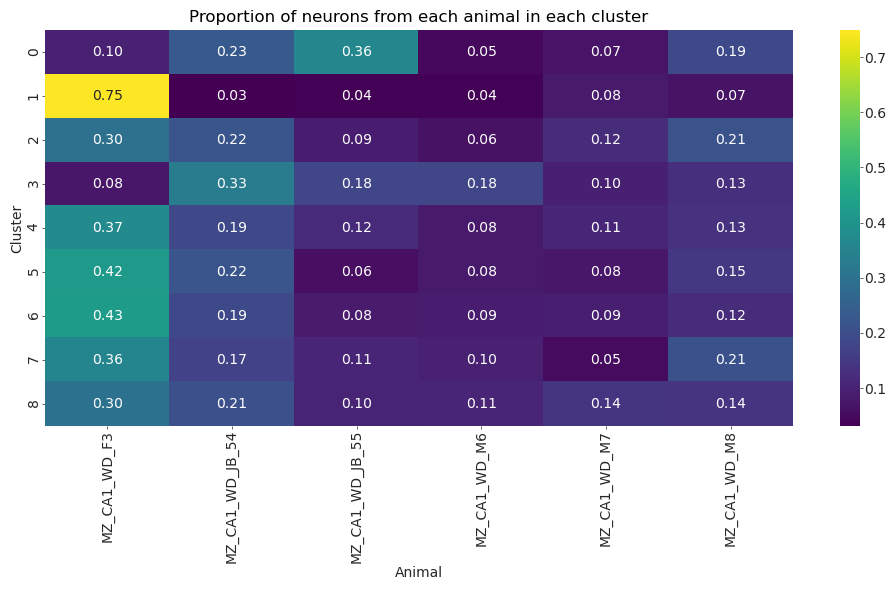

In [12]:
## -------------------------------------------------------------------------------------------------------
# Plots
# Plot animal's contribution for each cluster
df_contrib_by_animal = pd.DataFrame(
    {'Animal': population_animal_id,
        'Cluster': clusterlabel_list}
)
cluster_counts = df_contrib_by_animal.groupby(['Cluster', 'Animal']).size().unstack(fill_value=0)
cluster_percent_each_animal = cluster_counts.divide(cluster_counts.sum(axis=1), axis=0)
# print("\nNeuron counts per cluster per animal:")
# print(cluster_counts)
# Save as CSV
cluster_counts.to_csv(os.path.join(result_dir, "cluster_counts.csv"))
cluster_percent_each_animal.to_csv(os.path.join(result_dir, "cluster_percent.csv"))

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_percent_each_animal, annot=True, cmap="viridis", fmt=".2f")
plt.title("Proportion of neurons from each animal in each cluster")
plt.ylabel("Cluster")
plt.xlabel("Animal")
plt.tight_layout()
# plt.savefig(os.path.join(result_dir, "cluster_contribution_heatmap.svg"))
plt.savefig(os.path.join(result_dir, "cluster_contribution_heatmap.png"))
plt.show()


findfont: Font family ['sans-serif'] not found. Falling back to DejaVu Sans.


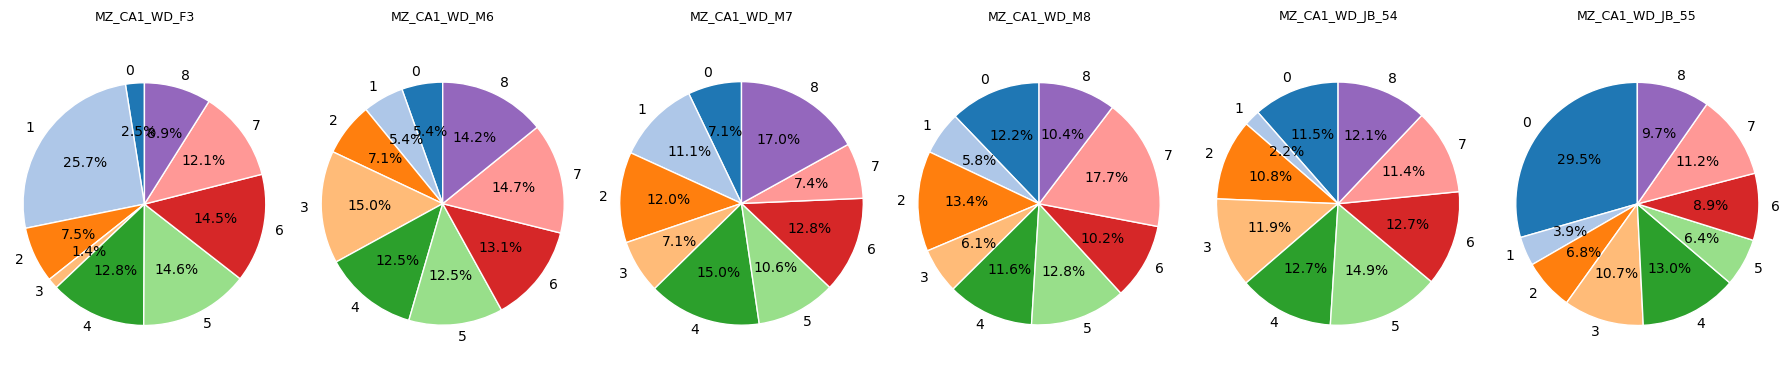

In [13]:
# Plot pie charts for each animal in subplots
num_animals = len(animal_list)
fig, axes = plt.subplots(1, num_animals, figsize=(num_animals * 3, 4))
colors = cm.get_cmap('tab20').colors  # Use a colormap with enough distinct colors

for ax, animal in zip(axes, animal_list):
    # Get the counts of each cluster for the current animal
    counts = cluster_counts[animal]
    
    # Plot pie chart
    ax.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90, colors=colors)
    ax.set_title(f"{animal}", fontsize=9)
    ax.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.

fig.tight_layout()
fig.savefig(os.path.join(result_dir, "cluster_distribution_within_animal.png"))

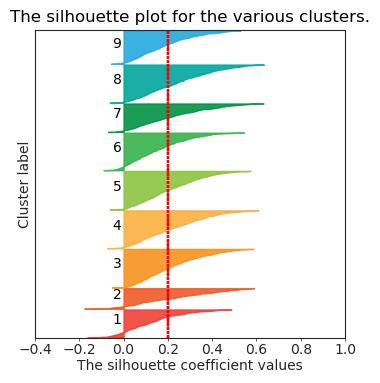

In [14]:
# Plot silhouette coefficient scores for each cluster
fig_silouette = make_silhouette_plot(
    transformed_data[:, :num_retained_pcs], model.labels_
)
fig_silouette.savefig(os.path.join(result_dir, "silouette.png"), format="png")
# plt.close(fig_silouette)

No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles with labels found to put in legend.
No handles wi

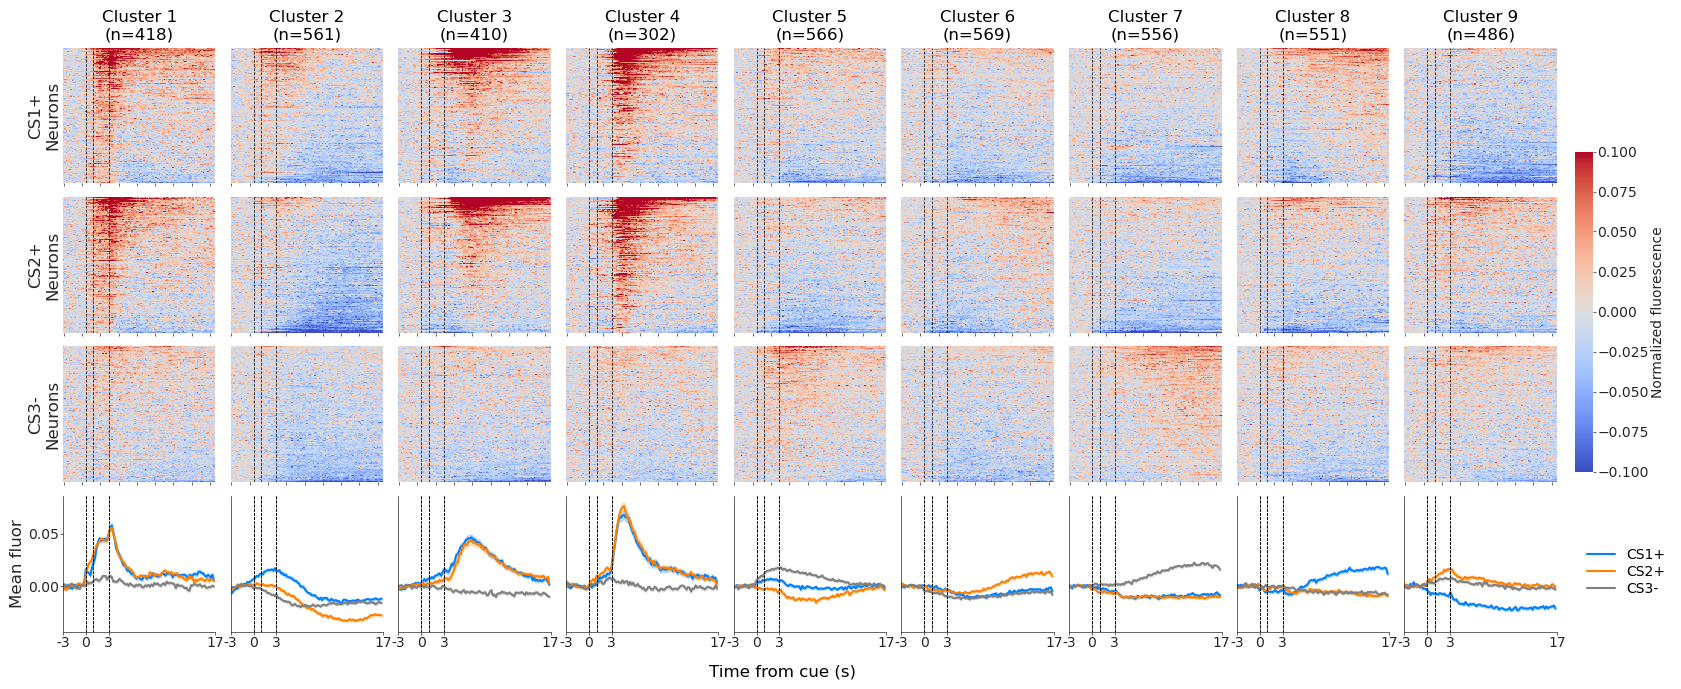

In [15]:
# Plot activity clusters under each CS
fig_activity_cluster = plot_activity_clusters(
    train_data,
    uniquelabels,
    clusterlabel_list,
    trial_types,
    [15, 100],
    window_size,
    pre_window_size,
    frames_to_reward,
    framerate,
)
fig_activity_cluster.savefig(
    os.path.join(result_dir, "activity_clusters.png"), format="png"
)

In [44]:
cell_keys = []
for i in range(num_animals):                    # MUST be the same order used to build labels
    for ip, ids in enumerate(population_cellidx[i]):
        for cid in ids:
            cell_keys.append((animal_list[0], ip, int(cid)))

assert len(cell_keys) == len(clusterlabel_list)

c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
c:\Users\mzhou9\Anaconda3\envs\py3\lib\site-packages\sklearn\manifold\_t_sne.py:790: FutureWarning: The default learning rate in TSNE will change from 200.0 to 'auto' in 1.2.
  warnings.warn(
c:\Users\mzhou9\Anaconda3\envs\py3\lib\s

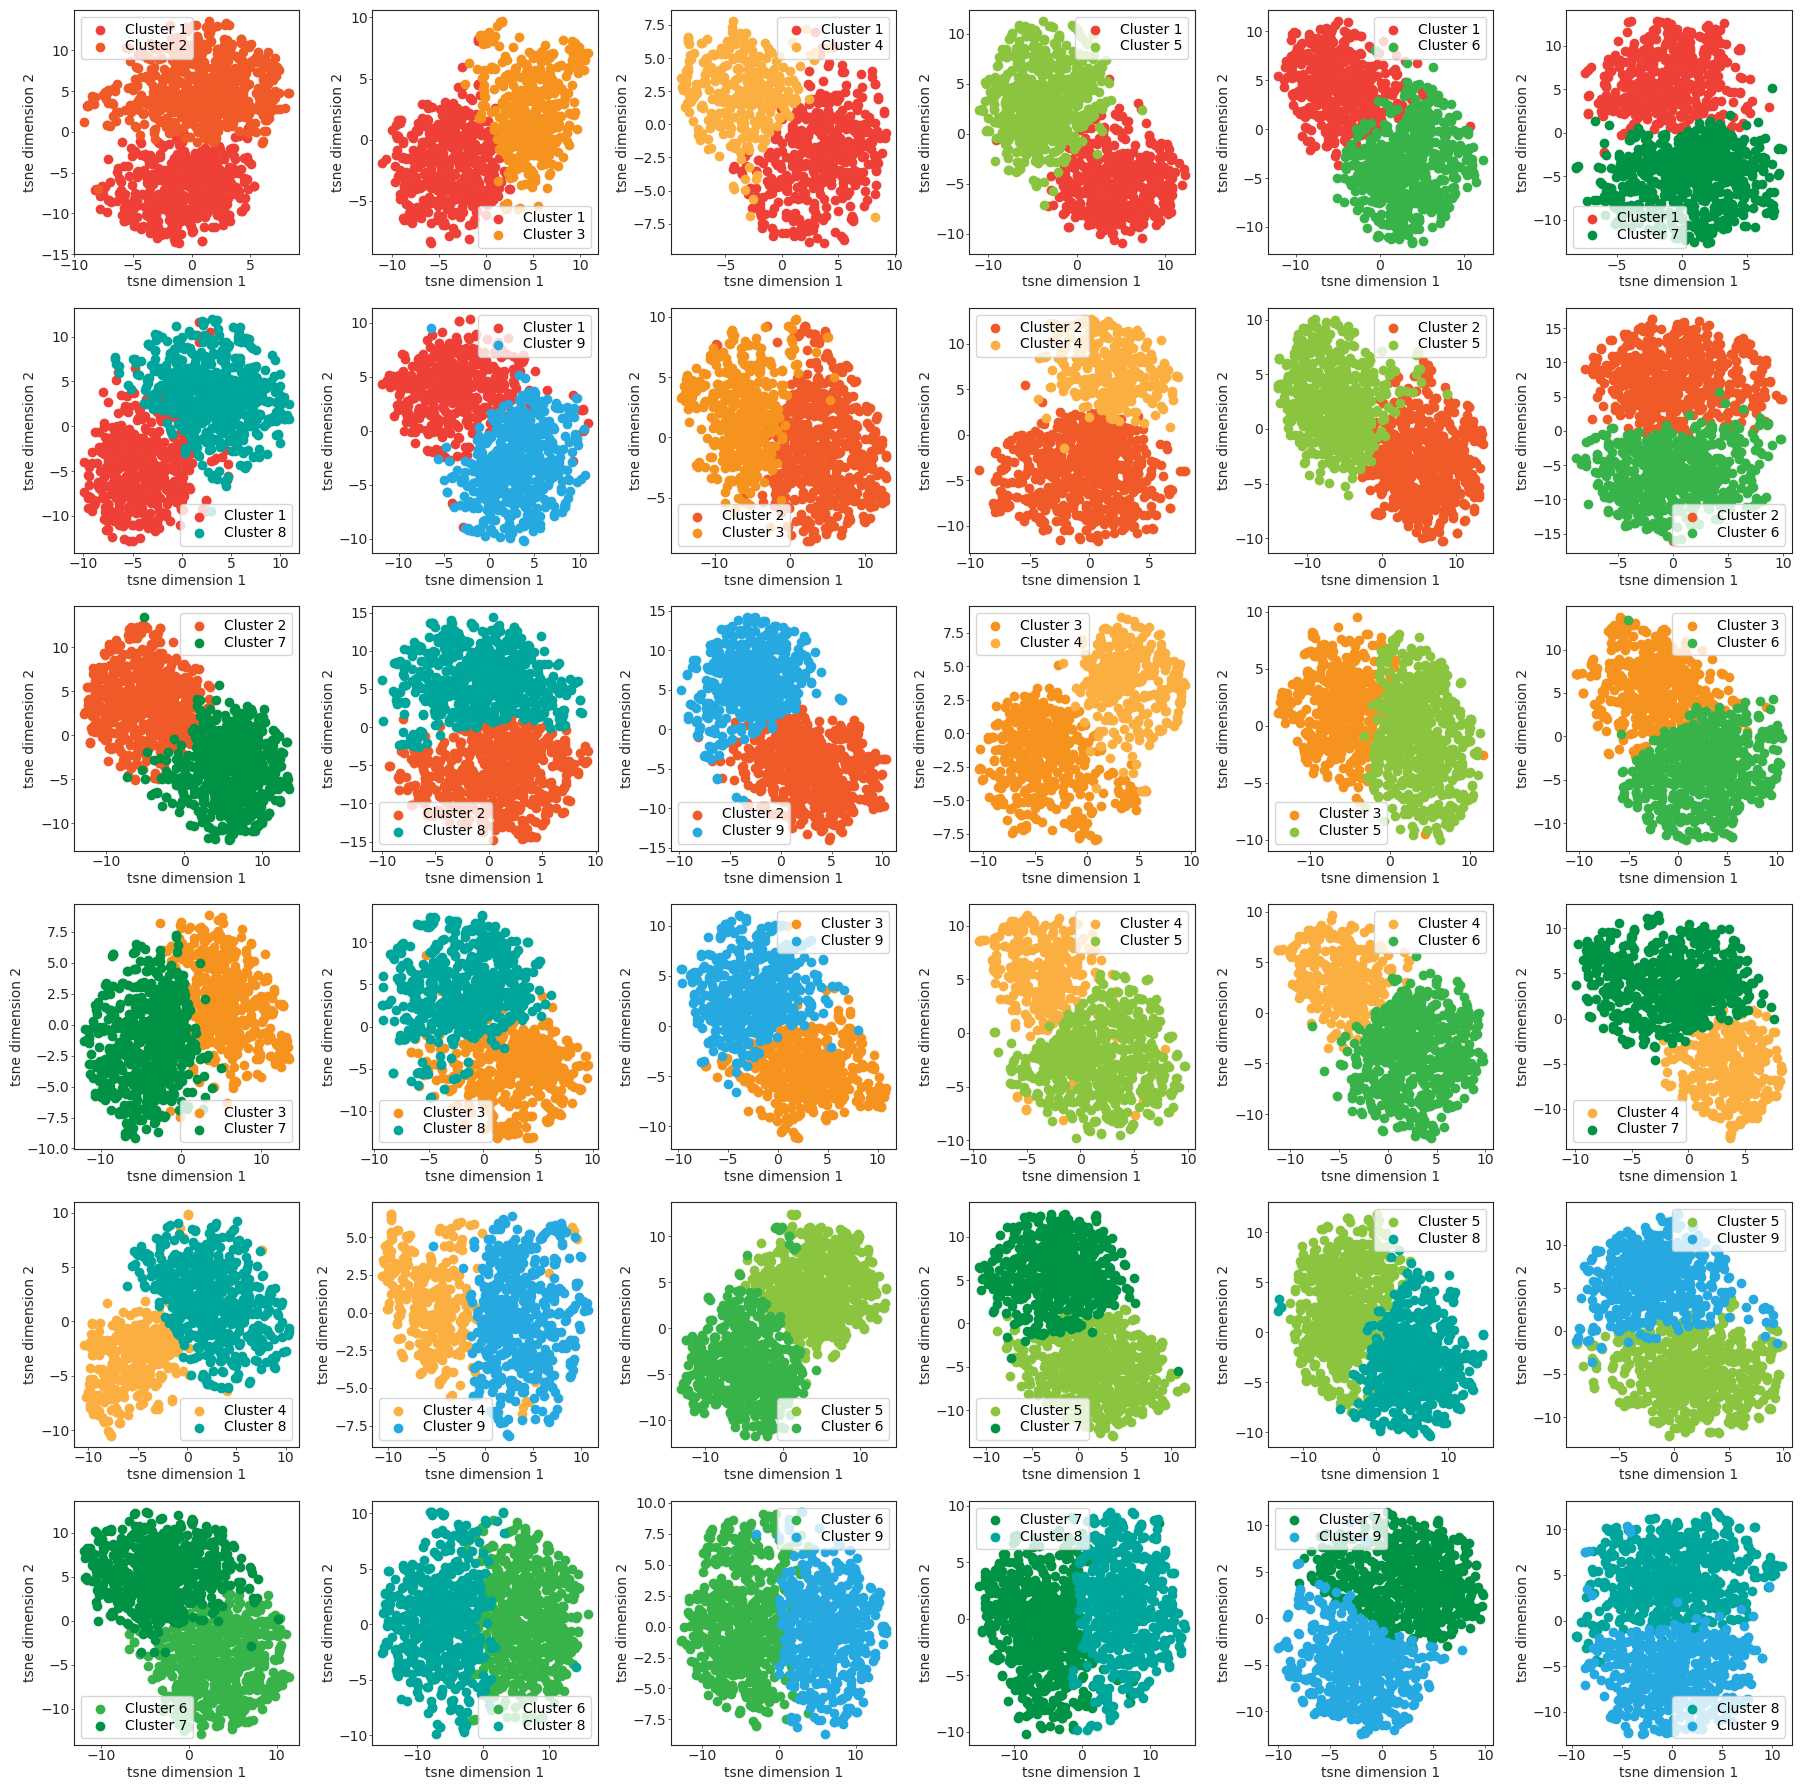

In [16]:
# Plot all cluster pairs
fig_cluster_pairs = plot_cluster_pairs(
    transformed_data, uniquelabels, clusterlabel_list, num_retained_pcs
)
fig_cluster_pairs.savefig(os.path.join(result_dir, "cluster_pairs.png"), format="png")

### This section and belows analyzes ROIs registered across sessions

In [17]:

# Load ROI ID for each animal on the previous training day "late"

# # Across learning stages
# target_day_list = [[1, 2, 3, 7, 10],
#                    [1, 2, 3, 6, 10],
#                    [1, 2, 4, 6, 9],
#                    [1, 2, 4, 6, 9],
#                    [1, 2, 3, 5, 9],
#                    [1, 2, 3, 5, 7, 10],
#                    [1, 2, 3, 9, 14]]
# target_day_list = [[1, 3, 7, 10],
#                 #    [1, 3, 6, 10],
#                    [1, 4, 5, 9],
#                    [1, 4, 6, 9],
#                    [1, 4, 6, 9],
#                    [1, 4, 8, 10],
#                    [1, 7, 12, 14]]

# Just early and late day
target_day_list = [[1, 7],
                   [1, 5],
                   [1, 6],
                   [1, 6],
                   [1, 8],
                   [1, 12]]

# # ## Late day and the previous day
# target_day_list = [[6, 7],
#                    [4, 5],
#                    [5, 6],
#                    [5, 6],
#                    [7, 8],
#                    [11, 12]]

# two late days + two two-reward days
# target_day_list = [
#     [6, 7, 8],
#     [5, 6, 7],
#     [6, 7, 8],
#     [6, 7, 8],
#     [8, 9, 10],
#     [12, 13, 14]
# ]

skip_map = {"MZ_CA1_WD_F3": 2} # (plane_index, day_index) to skip missing data, here skipping plane2 for F3 entirely
filtered_ROIs_across_sessions, filtered_labels = get_filtered_rois_per_animal_plane(animal_list, day_list, data_dir, clusterlabel_list, target_day_list, skip_map)

# # Show all rows in the output
# pd.set_option('display.max_rows', None)
# df = filtered_ROIs_across_sessions['MZ_CA1_WD_F3'][0]

MZ_CA1_WD_F3
Number of planes: 4
MZ_CA1_WD_F3 1635 1635
[   0  388  854 1297]
Skipping animal MZ_CA1_WD_F3, plane 2
MZ_CA1_WD_M6
Number of planes: 1
MZ_CA1_WD_M6 367 367
[0]
MZ_CA1_WD_M7
Number of planes: 1
MZ_CA1_WD_M7 407 407
[0]
MZ_CA1_WD_M8
Number of planes: 3
MZ_CA1_WD_M8 657 657
[  0 296 523]
MZ_CA1_WD_JB_54
Number of planes: 1
MZ_CA1_WD_JB_54 837 837
[0]
MZ_CA1_WD_JB_55
Number of planes: 1
MZ_CA1_WD_JB_55 516 516
[0]


In [18]:
## Check total number of ROIs across sessions
totalcells = 0

for animal in filtered_ROIs_across_sessions.keys():
    nplanes = len(filtered_ROIs_across_sessions[animal])
    for np in range(nplanes):
        n = len(filtered_ROIs_across_sessions[animal][np])
        # print(f"Animal {animal}, Plane {np}: {n} cells")
        totalcells += n
print(totalcells, "tracked ROIs across all animals and planes")
print(populationdata.shape[0], "total cells in the pooled data")
print(float(totalcells / populationdata.shape[0] * 100), "% of total cells tracked across days")

2087 tracked ROIs across all animals and planes
4419 total cells in the pooled data
47.227879610771666 % of total cells tracked across days


## Load and plot clustered cells on different individual days

In [87]:
test_day_list = np.ones(6, dtype=int) # input signle day for each animal
# test_day_list = [7, 6, 5, 6, 6, 8, 12]

animal_list = [
        "MZ_CA1_WD_F3",
        # "MZ_CA1_WD_M5",
        "MZ_CA1_WD_M6",
        "MZ_CA1_WD_M7",
        "MZ_CA1_WD_M8",
        "MZ_CA1_WD_JB_54",
        "MZ_CA1_WD_JB_55",
    ]
filtered_d1, animal_id_list, foundcell_idx, new_labels_d1 = load_population_data_filtered(
    animal_list, 
    test_day_list, 
    data_dir, 
    result_dir, 
    target_frames, 
    pre_cue_window, 
    framerate, 
    filtered_ROIs_across_sessions)

# Plot activity clusters under each CS
# fig_activity_cluster_d1 = plot_activity_clusters(
#     filtered_d1,
#     uniquelabels,
#     new_labels_d1,
#     trial_types,
#     [15, 100],
#     window_size,
#     pre_window_size,
#     frames_to_reward,
#     framerate,
# )
# fig_activity_cluster.savefig(
#     os.path.join(result_dir, "activity_clusters_day1.svg"), format="svg"
# )

AttributeError: 'int' object has no attribute 'ones'

## Load and plot clustered cells on multiple days 

In [99]:
importlib.reload(s2p_utils.processing_utils)
from s2p_utils.processing_utils import load_population_data_multiday
# intermediate_day_list = [3, 3, 4, 4, 4, 4, 7]
# trained_day_list = [7, 6, 5, 6, 6, 8, 12]
# two_reward_last_day = [10, 10, 9, 9, 9, 10, 14]
# days_per_animal = [[1, 3, 7, 10],
#                 #    [1, 3, 6, 10],
#                    [1, 4, 5, 9],
#                    [1, 4, 6, 9],
#                    [1, 4, 6, 9],
#                    [1, 4, 8, 10],
#                    [1, 7, 12, 14]]
## first day, trained day
# days_per_animal = [[1, 7],
#                    [1, 5],
#                    [1, 6],
#                    [1, 6],
#                    [1, 8],
#                    [1, 12]]

## first day, trained day and two reward days
# days_per_animal = [[1, 7, 10],
#                 #    [1, 3, 6, 10],
#                    [1, 5, 9],
#                    [1, 6, 9],
#                    [1, 6, 9],
#                    [1, 8, 10],
#                    [1, 12, 14]]
pop, animal_id, cell_keys_commondf, cell_keys_ref, labels_acrosssessions, day_order = load_population_data_multiday(
    animal_list=animal_list,
    days_per_animal=target_day_list,
    data_dir=data_dir,
    target_frames=target_frames,
    pre_cue_window=pre_cue_window,
    framerate=framerate,
    filtered_rois_per_animal_plane=filtered_ROIs_across_sessions,
    subtrials="all",
    reference_day_index=1
)


=== Loading MZ_CA1_WD_F3 days [1, 7] ===
 Reference day: 7 (key 6)
[154, 27, 408, 22, 87, 106, 19, 135, 7, 300, 15, 485, 226, 28, 278, 88, 246, 101, 580, 302, 222, 401, 80, 255, 289, 82, 232, 139, 425, 47, 164, 56, 184, 55, 147, 930, 353, 84, 120, 5, 34, 423, 314, 274, 328, 125, 98, 196, 13, 176, 455, 85, 217, 132, 392, 418, 86, 128, 254, 79, 83, 37, 129, 426, 172, 141, 29, 299, 356, 496, 216, 451, 596, 181, 345, 396, 295, 253, 2, 514, 256, 746, 180, 137, 599, 263, 297, 830, 130, 386, 243, 473, 513, 144, 212, 420, 96, 262]
[1, 3, 6, 7, 12, 13, 14, 16, 17, 19, 20, 21, 24, 26, 30, 33, 34, 37, 42, 47, 49, 60, 73, 76, 79, 95, 98, 101, 103, 106, 108, 116, 119, 120, 130, 134, 142, 143, 146, 148, 151, 155, 157, 168, 174, 177, 184, 188, 202, 205, 211, 212, 221, 231, 236, 275, 278, 293, 296, 300, 311, 312, 317, 325, 328, 337, 340, 353, 366, 390, 391, 407, 414, 428, 446, 478, 480, 482, 505, 550, 553, 564, 575, 597, 600, 608, 628, 723, 751, 763, 906, 1055, 1134, 1143, 1172, 1260, 1439, 1440]
  M

In [95]:
with open("cell_keys_ref.txt", "w") as f:
    for i, t in enumerate(cell_keys_ref):
        f.write(f"{i}: {t}\n")

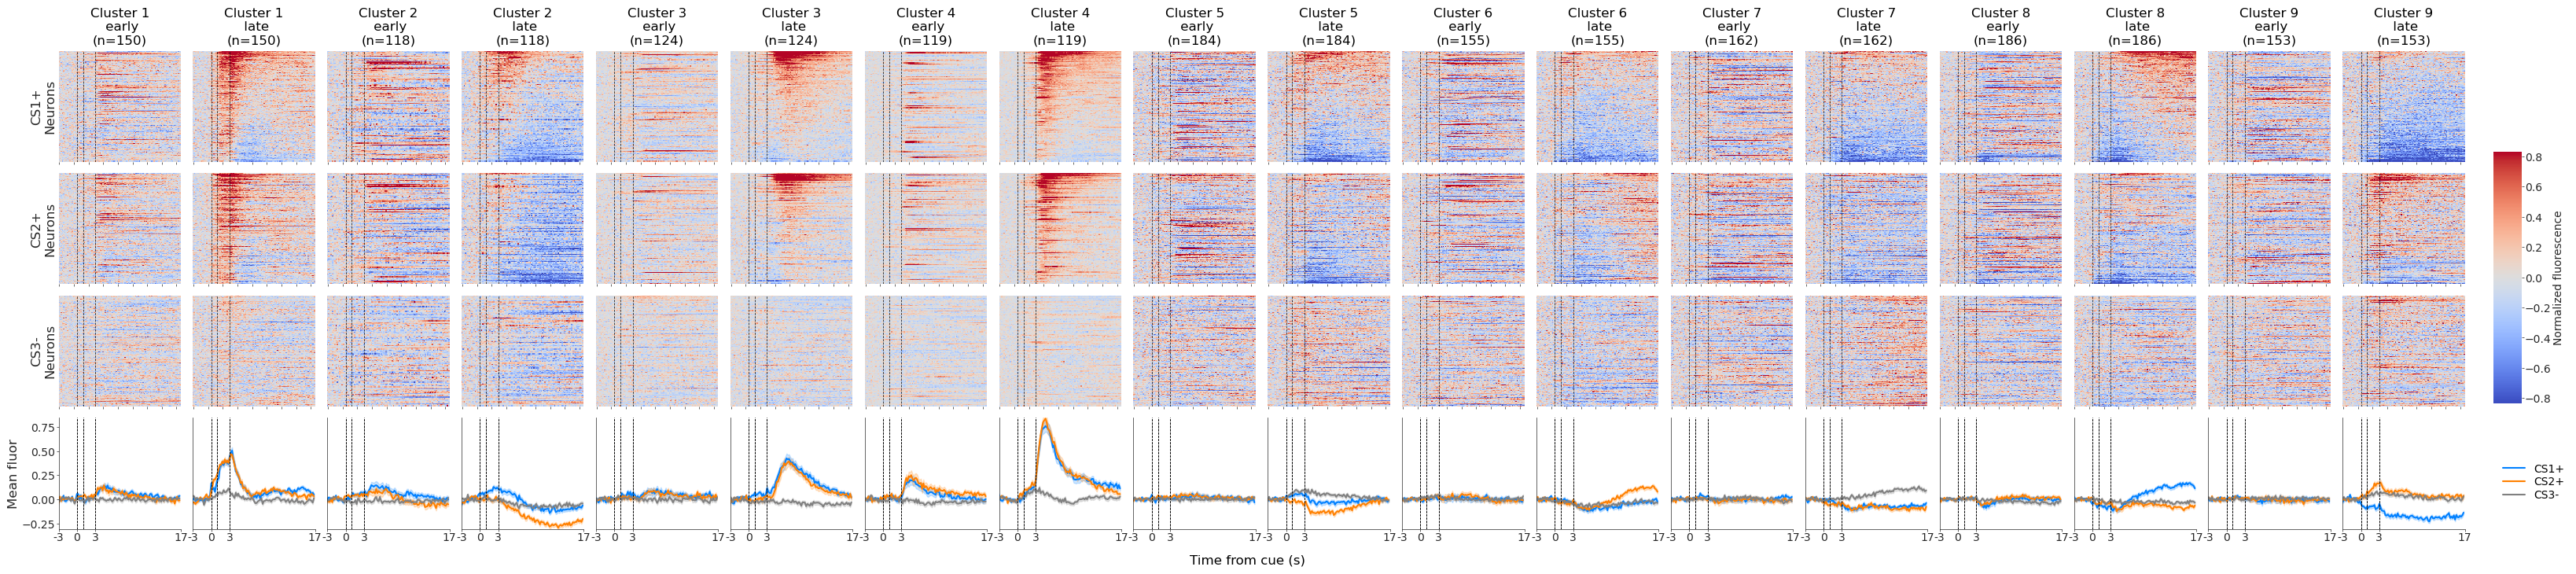

In [116]:
import importlib, plot_utils
importlib.reload(plot_utils)
from plot_utils import plot_activity_clusters_pooled_multiday

daylabels = ['early','late']

fig_clustered_multiday, plotted_cells = plot_activity_clusters_pooled_multiday(
    populationdata=pop,
    cell_keys_reference=cell_keys_ref,
    labels=labels_acrosssessions,
    uniquelabels=uniquelabels,
    numdays=len(daylabels),
    trial_types=trial_types,
    sortwindow=[15, 90],
    window_size=window_size,
    pre_window_size=pre_window_size,
    frames_to_reward=frames_to_reward,
    framerate=framerate,
    day_labels=daylabels,
    reference_day=1,
    percent_keep=1
)
#
# fig_clustered_multiday.savefig(os.path.join(result_dir, "activity_clusters_earlyvslate.png"), format="png")

In [102]:
# Plot example cells across learning from each cluster
for cluster in plotted_cells.keys():
    example_idx = plotted_cells[cluster]['global_indices'][0:10]
    # example_idx = [plotted_cells[cluster]['global_indices'][i] for i in idx]

    fig_example_cells = plot_example_cells_across_learning(
    populationdata=pop,
    cell_indices=example_idx,
    trial_types=trial_types,
    window_size=window_size,
    pre_window_size=pre_window_size,
    frames_to_reward=frames_to_reward,
    framerate=framerate,
    day_labels=daylabels,
    )
    fig_example_cells.savefig(os.path.join(result_dir, f"example_cells_cluster{cluster+1}_earlyvslate.png"), format="png")
    plt.close(fig_example_cells)

## Plot CS1 vs CS2 

In [ ]:
# Plot CS2 activity clustered by CS1vsCS3
# cs2_data = pca.transform(cs2_data)[:, :num_retained_pcs]
colors_for_key = {}
colors_for_key["CS1+"] = (0, 0.5, 1)
colors_for_key["CS2+"] = (1, 0.5, 0)
colors_for_key["CS3-"] = (0.5, 0.5, 0.5)
trial_types = ['CS1+', 'CS3-']
global_min = np.inf
global_max = -np.inf

fig, axs = plt.subplots(1, len(uniquelabels), figsize=(3*len(uniquelabels), 3))
for c, cluster in enumerate(uniquelabels):
    for k, tempkey in enumerate(trial_types):
        temp = train_data[
            np.where(newlabels == cluster)[0],
            k * window_size : (k + 1) * window_size,
        ]
        if temp.size > 0:
            mean_response = np.mean(temp, axis=0)
            global_min = min(global_min, np.min(mean_response))
            global_max = max(global_max, np.max(mean_response))
        
        ax = axs[c] if n_clusters > 1 else axs
        ax = tsplot(
                    temp,
                    ax=ax,
                    color=colors_for_key[tempkey],
                    label=tempkey if (cluster == (len(uniquelabels) - 1)) else None,
                )
        ax.axvline(pre_window_size, linestyle="--", color="k", linewidth=0.5)
        ax.axvline(
            pre_window_size + frames_to_reward,
            linestyle="--",
            color="k",
            linewidth=0.5,
        )
        ax.set_xticks(
            [0, pre_window_size, pre_window_size + frames_to_reward, window_size]
        )
        ax.set_xticklabels(
            [
                str(int((a - pre_window_size + 0.0) / framerate))
                for a in [
                    0,
                    pre_window_size,
                    pre_window_size + frames_to_reward,
                    window_size,
                ]
            ]
        )
        
    # Plot CS2 activity
    cs2_data_bycluster = cs2_data[newlabels == cluster]
    ax = tsplot(
            cs2_data[newlabels == cluster],
            ax=ax,
            color=colors_for_key['CS2+'],
            label=tempkey if (cluster == (len(uniquelabels) - 1)) else None,
        )
    if cluster == 0:
        buffer = 0.01
        ax.set_ylim([global_min - buffer, global_max + buffer])
    else:
        ax.set_yticks([])
    
    ax.legend(
        bbox_to_anchor=(0.94, 0.22),
        bbox_transform=fig.transFigure,
        frameon=False,
    )
    standardize_plot_graphics(ax)    
    axs[0].set_ylabel("Mean fluor")
    axs[cluster].set_title(
        "Cluster %d\n" % (cluster + 1)
    )
    fig.text(
        0.5,
        0.05,
        "Time from cue (s)",
        fontsize=12,
        horizontalalignment="center",
        verticalalignment="center",
        rotation="horizontal",
    )
fig.show()
fig.tight_layout()
# plt.show()
fig.savefig(os.path.join(result_dir, "CS2_activity_by_CS1cluster.svg"), format='svg')

In [ ]:
newdir = os.path.join(result_dir, 'all trials')
pop_path = os.path.join(newdir, "populationdata.npy")

popdata_all = np.load(pop_path, allow_pickle=True)

In [ ]:
from scipy.ndimage import gaussian_filter1d

traj_data = transformed_data.T  # shape: [300 timepoints, n_PCs]

# Split into three conditions
timesteps = 100
cs1_traj = traj_data[0:100, :]
cs2_traj = traj_data[100:200, :]
cs3_traj = traj_data[200:300, :]

cs1_traj = gaussian_filter1d(cs1_traj, sigma=2, axis=0)
cs2_traj = gaussian_filter1d(cs2_traj, sigma=2, axis=0)
cs3_traj = gaussian_filter1d(cs3_traj, sigma=2, axis=0)

# Plot the first 3 principal components
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.plot(cs1_traj[:, 0], cs1_traj[:, 1], cs1_traj[:, 2], color=colors_for_key['CS1+'], label='CS1+')
ax.plot(cs2_traj[:, 0], cs2_traj[:, 1], cs2_traj[:, 2], color=colors_for_key['CS2+'], label='CS2+')
# ax.plot(cs3_traj[:, 0], cs3_traj[:, 1], cs3_traj[:, 2], color='b', label='CS3+')

# Mark start and end points
ax.scatter(cs1_traj[0, 0], cs1_traj[0, 1], cs1_traj[0, 2], color=colors_for_key['CS1+'], marker='o')
ax.scatter(cs2_traj[0, 0], cs2_traj[0, 1], cs2_traj[0, 2], color=colors_for_key['CS2+'], marker='o')
# ax.scatter(cs3_traj[0, 0], cs3_traj[0, 1], cs3_traj[0, 2], color='b', marker='o')

ax.scatter(cs1_traj[-1, 0], cs1_traj[-1, 1], cs1_traj[-1, 2], color=colors_for_key['CS1+'], marker='x')
ax.scatter(cs2_traj[-1, 0], cs2_traj[-1, 1], cs2_traj[-1, 2], color=colors_for_key['CS2+'], marker='x')
# ax.scatter(cs3_traj[-1, 0], cs3_traj[-1, 1], cs3_traj[-1, 2], color='b', marker='x')

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Neural Trajectories in PCA Space')
ax.legend()
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

all_trials_data = transformed_data.T.reshape(len(trial_types), window_size, -1)


colors_for_key = {}
colors_for_key["CS1+"] = (0, 0.5, 1)
colors_for_key["CS2+"] = (1, 0.5, 0)
colors_for_key["CS3-"] = (0.5, 0.5, 0.5)

labels_unique = sorted(set(labels))  # e.g., ['CS1+', 'CS2+', 'CS3+']

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

for label in labels_unique:
    # Get indices for this condition
    idx = [i for i, l in enumerate(labels) if l == label]

    for i in idx:
        traj = all_trials_data[i]  # shape: [timepoints, n_pcs]
        start = traj[0, :3]  # first 3 PCs
        end = traj[-1, :3]

        # Connect start to end
        ax.plot([start[0], end[0]], [start[1], end[1]], [start[2], end[2]], 
                color=colors_for_key[label], alpha=0.4)

        # Mark points
        ax.scatter(*start, color=colors_for_key[label], marker='o', s=20)  # start
        ax.scatter(*end, color=colors_for_key[label], marker='x', s=30)    # end

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Start and End of Neural Trajectories')
ax.legend(labels_unique)
plt.show()

In [ ]:
all_trials_data = transformed_data.reshape(len(trial_types), window_size, -1)
